In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/dataset.csv")
print(df.shape)   # (jumlah baris, jumlah kolom)
df.head()

(85496, 11)


,datetime,main.aqi,components.co,components.no,components.no2,components.o3,components.so2,components.pm2_5,components.pm10,components.nh3,city_name
0,2026-09-01 00:00:00+08:00,2.0,139.32,0.0,0.26,64.05,0.21,11.45,21.74,0.06,Alaminos
1,2026-09-01 00:00:02+08:00,2.0,218.42,0.0,0.22,85.81,0.23,13.37,30.16,0.55,Angeles City
2,2026-09-01 00:00:04+08:00,2.0,233.01,0.0,1.11,81.92,0.60,9.25,16.91,0.72,Antipolo
3,2026-09-01 00:00:07+08:00,1.0,168.57,0.0,2.79,32.26,0.64,4.53,6.12,1.32,Bacolod
4,2026-09-01 00:00:09+08:00,2.0,252.49,0.0,0.25,92.17,0.21,9.30,21.69,0.78,Bacoor


In [4]:
kolom = df["components.co"]
# kolom.mean(), kolom.median(), kolom.mode()[0]
# kolom.var(), kolom.std()
# kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

,main.aqi,components.co,components.no,components.no2,components.o3,components.so2,components.pm2_5,components.pm10,components.nh3
count,85496.000000,85496.000000,85496.000000,85496.000000,85496.000000,85496.000000,85496.000000,85496.000000,85496.000000
mean,1.461039,208.074861,0.064639,1.659076,53.813567,0.859230,7.156114,8.991967,1.148741
std,0.667810,86.329156,0.202382,2.280637,21.879674,1.322975,10.162967,11.020056,2.149552
min,1.000000,72.350000,0.000000,0.030000,0.390000,0.010000,0.500000,0.500000,0.000000
25%,1.000000,146.470000,0.000000,0.320000,42.550000,0.140000,2.100000,3.040000,0.120000
50%,1.000000,189.190000,0.010000,0.720000,51.795000,0.330000,3.580000,5.480000,0.390000
75%,2.000000,249.920000,0.050000,2.060000,63.290000,1.060000,7.270000,9.930000,1.140000
max,5.000000,956.280000,4.610000,40.700000,287.590000,18.090000,154.800000,169.630000,33.140000


In [5]:
import math

kolomKolom = df[["components.co", "components.pm2_5", "components.o3"]]

def membuatTabelRingkasan(koloms):
    hasilTabel = {}
    for namaKolom in koloms.columns:
            kolom = df[namaKolom]
            Q1 = kolom.quantile(0.25)
            Q3 = kolom.quantile(0.75)
            hasilTabel[namaKolom] = {
                "Rata-rata": kolom.mean(), 
                "Median": kolom.median(), 
                "Modus": kolom.mode()[0], 
                "Mininim": kolom.min(), 
                "Maximum": kolom.max(), 
                "jangkauan": kolom.max() - kolom.min(), 
                "Varians": kolom.var(), 
                "Simpanan Baku": kolom.std(),  
                "Q1": Q1,  
                "Q3": Q3,  
                "IQR": Q3 - Q1,  
                }
    
    return pd.DataFrame(data=hasilTabel)

print("===== Tabel Ringkasan =====\n")
print(membuatTabelRingkasan(kolomKolom), "\n\n")



# Perhitungan Manual
kolomCO = df["components.co"]
kolomCOHead10 = kolomCO.head(10)
# Cari rata-ratanya
rataRata = kolomCOHead10.mean()
print("===== Hitung Manual Menggunakan Rumus =====\n")
print("Mean dari 10 baris teratas: ", kolomCOHead10.mean())

sumOfDeviasi = 0
for i in range (len(kolomCOHead10)):
    deviasi = (kolomCOHead10[i] - rataRata) ** 2
    print(f"deviasi row {i}: ", deviasi)
    sumOfDeviasi += deviasi

print("Jumlah deviasi: ", sumOfDeviasi)
print("Varians (manual): ", )

print("Varians: ", kolomCOHead10.var())

print("Simapanan baku (manual): ", math.sqrt(sumOfDeviasi / 9))
print("Simapanan baku: ", kolomCOHead10.std())



===== Tabel Ringkasan =====

               components.co  components.pm2_5  components.o3
Rata-rata         208.074861          7.156114      53.813567
Median            189.190000          3.580000      51.795000
Modus             181.630000          1.590000      50.230000
Mininim            72.350000          0.500000       0.390000
Maximum           956.280000        154.800000     287.590000
jangkauan         883.930000        154.300000     287.200000
Varians          7452.723145        103.285893     478.720153
Simpanan Baku      86.329156         10.162967      21.879674
Q1                146.470000          2.100000      42.550000
Q3                249.920000          7.270000      63.290000
IQR               103.450000          5.170000      20.740000 


===== Hitung Manual Menggunakan Rumus =====

Mean dari 10 baris teratas:  180.54299999999998
deviasi row 0:  1699.3357289999988
deviasi row 1:  1434.6671290000006
deviasi row 2:  2752.7860890000015
deviasi row 3:  143.352728

In [6]:
# Menampilkan frekuensi kemunculan tiap kategori
print("5 Kota Teratas (Frekuensi):")
print(df["city_name"].value_counts().head(5))

# Menampilkan persentase kemunculan
print("\n5 Kota Teratas (Persentase):")
print(df["city_name"].value_counts(normalize=True).head(5) * 100)

5 Kota Teratas (Frekuensi):
city_name
Alaminos        623
Angeles City    623
Bacolod         623
Bago City       623
Baguio          623
Name: count, dtype: int64

5 Kota Teratas (Persentase):
city_name
Alaminos        0.728689
Angeles City    0.728689
Bacolod         0.728689
Bago City       0.728689
Baguio          0.728689
Name: proportion, dtype: float64


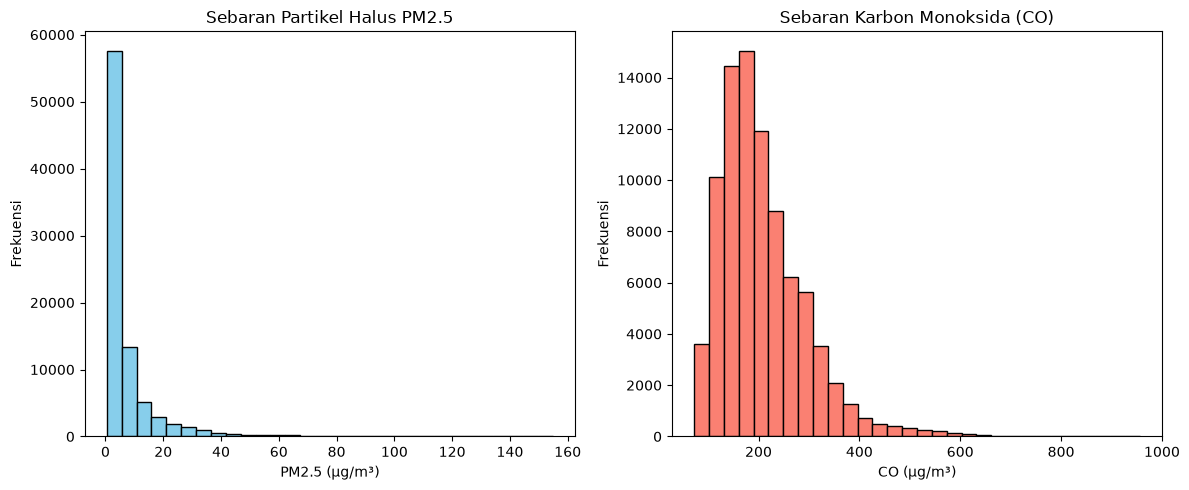

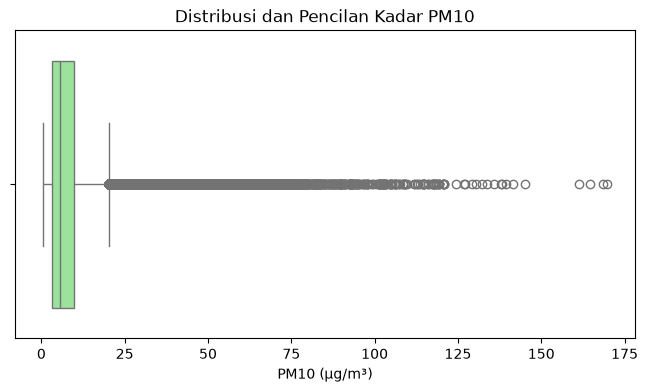

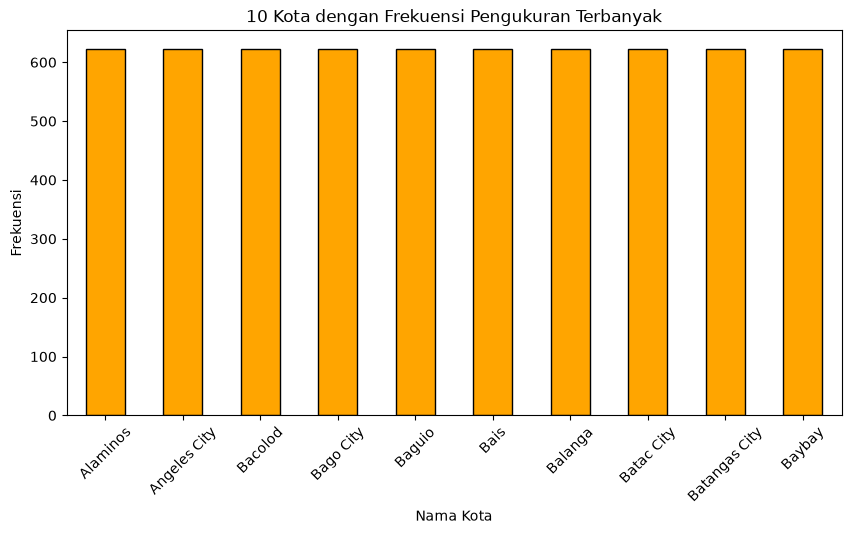

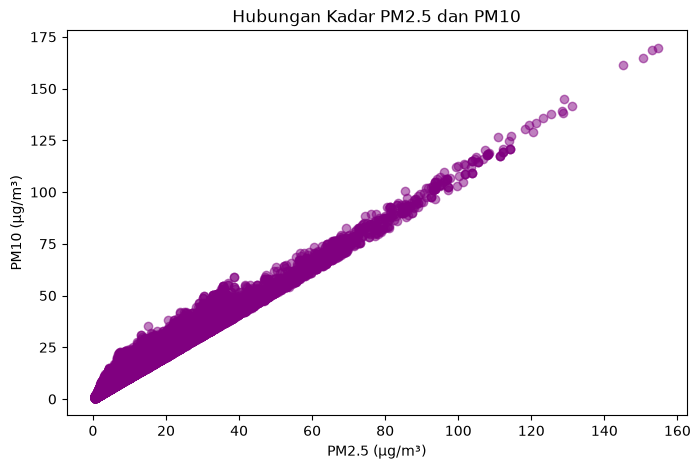

In [7]:

# 1. Histogram (2 Kolom Numerik: PM2.5 dan CO)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(df["components.pm2_5"], bins=30, color='skyblue', edgecolor='black')
ax[0].set_title("Sebaran Partikel Halus PM2.5")
ax[0].set_xlabel("PM2.5 (µg/m³)")
ax[0].set_ylabel("Frekuensi")

ax[1].hist(df["components.co"], bins=30, color='salmon', edgecolor='black')
ax[1].set_title("Sebaran Karbon Monoksida (CO)")
ax[1].set_xlabel("CO (µg/m³)")
ax[1].set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# 2. Boxplot (1 Kolom Numerik: PM10)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["components.pm10"], color='lightgreen')
plt.title("Distribusi dan Pencilan Kadar PM10")
plt.xlabel("PM10 (µg/m³)")
plt.show()

# 3. Diagram Batang (Kategorik: city_name)
plt.figure(figsize=(10, 5))
df["city_name"].value_counts().head(10).plot(kind='bar', color='orange', edgecolor='black')
plt.title("10 Kota dengan Frekuensi Pengukuran Terbanyak")
plt.xlabel("Nama Kota")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.show()

# 4. Scatter Plot (Korelasi PM2.5 dan PM10)
plt.figure(figsize=(8, 5))
plt.scatter(df["components.pm2_5"], df["components.pm10"], alpha=0.5, color='purple')
plt.title("Hubungan Kadar PM2.5 dan PM10")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("PM10 (µg/m³)")
plt.show()